In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load Dataset
df = pd.read_csv("Student_Exam_Pass.csv")
print(df.shape)
df.head()

(400, 5)


,StudentID,HoursStudied,AttendancePercent,PreviousScore,Passed
0,20000,3.7,46.2,79.5,1
1,20001,9.5,94.2,40.7,1
2,20002,7.3,70.3,70.3,1
3,20003,6.0,89.6,72.5,1
4,20004,1.6,59.2,59.7,0


In [3]:
df.describe()

,StudentID,HoursStudied,AttendancePercent,PreviousScore,Passed
count,400.000000,400.000000,400.000000,400.000000,400.000000
mean,20199.500000,4.944750,69.983250,65.248750,0.662500
std,115.614301,2.937259,17.627668,20.775829,0.473449
min,20000.000000,0.100000,40.700000,30.300000,0.000000
25%,20099.750000,2.400000,54.475000,46.275000,0.000000
50%,20199.500000,5.100000,70.200000,66.300000,1.000000
75%,20299.250000,7.500000,85.625000,83.550000,1.000000
max,20399.000000,9.900000,100.000000,99.900000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          400 non-null    int64  
 1   HoursStudied       400 non-null    float64
 2   AttendancePercent  400 non-null    float64
 3   PreviousScore      400 non-null    float64
 4   Passed             400 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 15.8 KB


In [5]:
# Features and Target
X = df[['HoursStudied','PreviousScore']]
y = df['Passed']

In [6]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Logistic Regression Model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [9]:
# Prediction
y_pred = model.predict(X_test)

In [10]:
# Accuracy
print("Accuracy :", accuracy_score(y_test,y_pred))

Accuracy : 0.75


In [11]:
# Confusion Matrix
print(confusion_matrix(y_test,y_pred))

[[17 14]
 [ 6 43]]


In [12]:
# Classification Report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.55      0.63        31
           1       0.75      0.88      0.81        49

    accuracy                           0.75        80
   macro avg       0.75      0.71      0.72        80
weighted avg       0.75      0.75      0.74        80



In [13]:
# Predict whether a student will pass based on hours studied and previous score
new_student = [[5.5, 65.0]]  # [HoursStudied, PreviousScore]
new_student = scaler.transform(new_student)
prediction = model.predict(new_student)
print("Predicted Passed label:", prediction[0])

Predicted Passed label: 1


/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


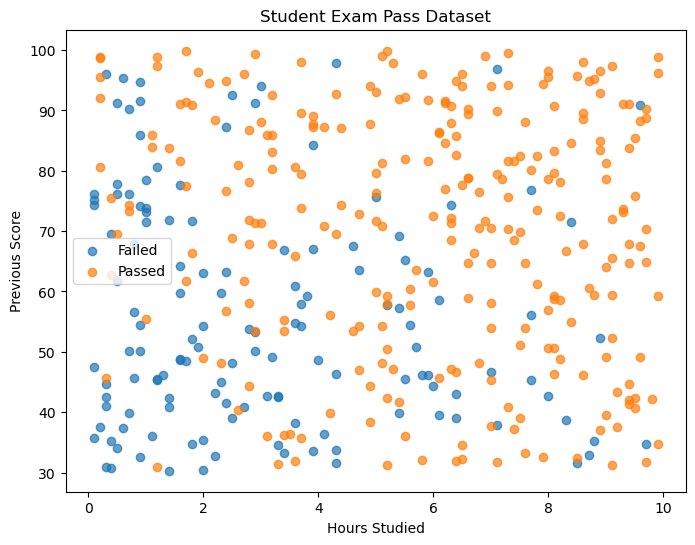

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(df[df['Passed']==0]['HoursStudied'],
            df[df['Passed']==0]['PreviousScore'],
            label='Failed', alpha=0.7)

plt.scatter(df[df['Passed']==1]['HoursStudied'],
            df[df['Passed']==1]['PreviousScore'],
            label='Passed', alpha=0.7)
plt.xlabel('Hours Studied')
plt.ylabel('Previous Score')
plt.title('Student Exam Pass Dataset')
plt.legend()
plt.show()

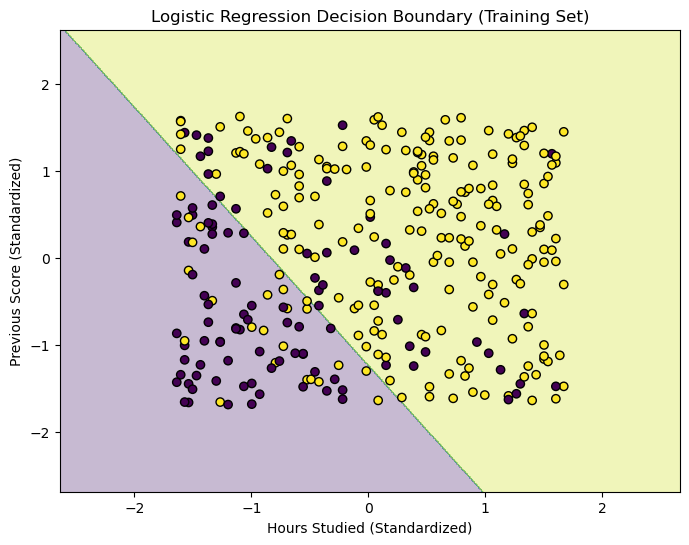

In [15]:
import numpy as np
import matplotlib.pyplot as plt
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:,0], X_train[:,1],
            c=y_train, edgecolor='k')
plt.xlabel("Hours Studied (Standardized)")
plt.ylabel("Previous Score (Standardized)")
plt.title("Logistic Regression Decision Boundary (Training Set)")
plt.show()

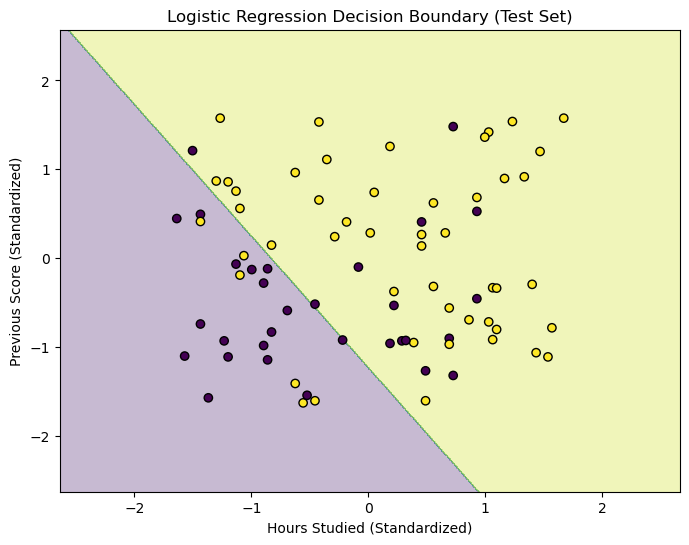

In [16]:
x_min, x_max = X_test[:,0].min()-1, X_test[:,0].max()+1
y_min, y_max = X_test[:,1].min()-1, X_test[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_test[:,0], X_test[:,1],
            c=y_test, edgecolor='k')

plt.xlabel("Hours Studied (Standardized)")
plt.ylabel("Previous Score (Standardized)")
plt.title("Logistic Regression Decision Boundary (Test Set)")
plt.show()

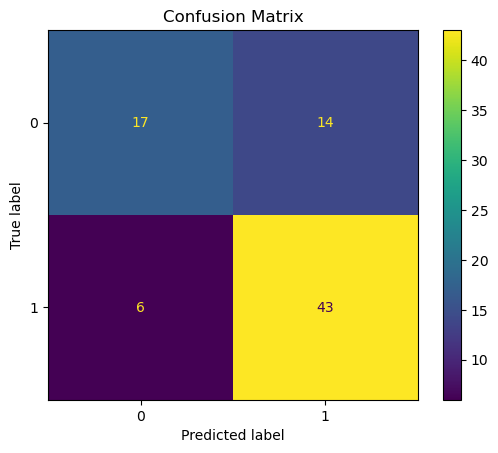

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()